# Checkpoint 2 — NYC Motor Vehicle Collisions
### Data preprocessing + readable summaries for our hypotheses

This notebook (1) loads and cleans the raw crash data, then (2) presents simple, easy‑to‑read
tables that let us draw a conclusion for each of our four hypotheses:

1. Which **vehicle type** is safest (fewest persons killed)?
2. What **time of day** has the most crashes / injuries / deaths?
3. Which **cross streets (intersections)** are the most dangerous?
4. Do the most crashes in **Manhattan** happen at a certain time?

Data source: [NYC Motor Vehicle Collisions – Crashes](https://data.cityofnewyork.us/Public-Safety/Motor-Vehicle-Collisions-Crashes/h9gi-nx95) (NYPD, NYC Open Data).

## 1. Data Preprocessing

The file `rows.json` is in the Socrata export format: a `meta` block with the column
definitions and a `data` block where each row is a list of values. We read the column names
from `meta`, build a DataFrame, drop the Socrata system columns, and convert each field to its
proper type.

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# (a) import
with open("rows.json") as f:
    raw = json.load(f)
columns = [c["fieldName"] for c in raw["meta"]["view"]["columns"]]
df = pd.DataFrame(raw["data"], columns=columns)
del raw
print("Rows:", f"{len(df):,}", "| Columns:", df.shape[1])

Rows: 2,267,222 | Columns: 37


In [2]:
# (b) parse + (c) organize
# Drop the 8 Socrata bookkeeping columns (they start with ":").
df = df.drop(columns=[c for c in df.columns if c.startswith(":")])

# Combine the crash date + separate crash time into one timestamp, then get the hour.
df["crash_datetime"] = pd.to_datetime(
    df["crash_date"].str[:10] + " " + df["crash_time"], errors="coerce"
)
df["hour"] = df["crash_datetime"].dt.hour

# Casualty counts are stored as strings -> convert to integers.
count_cols = [c for c in df.columns if c.startswith("number_of_")]
for c in count_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Clean up borough text.
df["borough"] = df["borough"].str.title()

print(df[["crash_datetime", "hour", "borough",
          "number_of_persons_injured", "number_of_persons_killed"]].head())

       crash_datetime  hour   borough  number_of_persons_injured  \
0 2021-09-11 02:39:00     2      None                        2.0   
1 2022-03-26 11:45:00    11      None                        1.0   
2 2023-11-01 01:29:00     1  Brooklyn                        1.0   
3 2022-06-29 06:55:00     6      None                        0.0   
4 2022-09-21 13:21:00    13      None                        0.0   

   number_of_persons_killed  
0                       0.0  
1                       0.0  
2                       0.0  
3                       0.0  
4                       0.0  


## 2. Hypothesis 1 — Safest vehicle type

Group by the primary vehicle type and look at the **total** and **average persons killed**.
We keep only common vehicle types (≥ 1,000 crashes) so the averages are reliable. The vehicle
with the **lowest average killed** is the safest.

In [3]:
v = df.groupby("vehicle_type_code1").agg(
    crashes=("collision_id", "count"),
    total_killed=("number_of_persons_killed", "sum"),
    avg_killed=("number_of_persons_killed", "mean"),
)
v = v[v["crashes"] >= 1000].sort_values("avg_killed")
v["avg_killed"] = v["avg_killed"].round(4)

print("SAFEST (lowest avg persons killed per crash):", v.index[0])
print("MOST DANGEROUS:", v.index[-1])
v

SAFEST (lowest avg persons killed per crash): Ambulance
MOST DANGEROUS: Motorcycle


,crashes,total_killed,avg_killed
vehicle_type_code1,,,
Ambulance,5357,1.0,0.0002
TAXI,31911,21.0,0.0007
LIVERY VEHICLE,10481,7.0,0.0007
4 dr sedan,43075,28.0,0.0007
SMALL COM VEH(4 TIRES),13216,10.0,0.0008
Carry All,2158,2.0,0.0009
PASSENGER VEHICLE,416206,398.0,0.0010
Taxi,57233,55.0,0.0010
OTHER,22968,23.0,0.0010


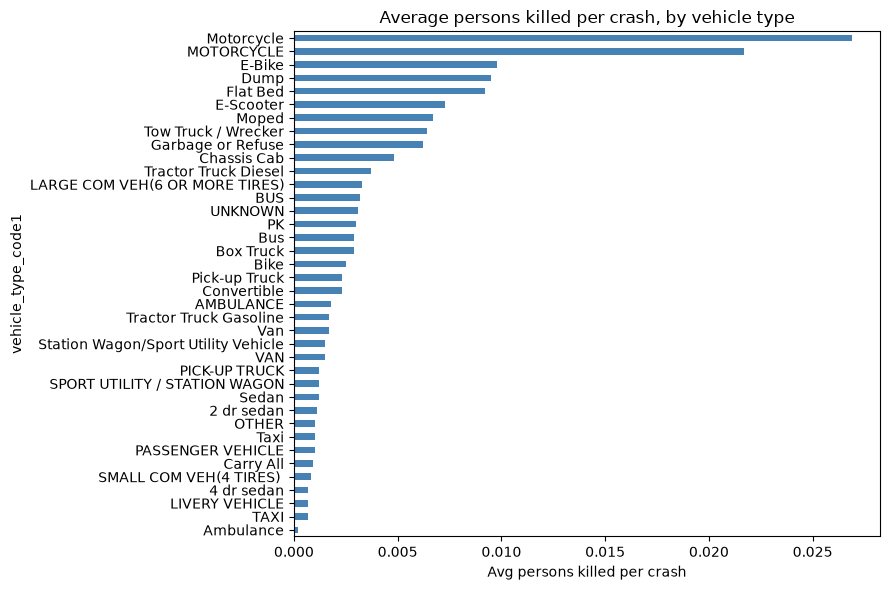

In [4]:
ax = v["avg_killed"].plot(kind="barh", figsize=(9, 6), color="steelblue")
ax.set_title("Average persons killed per crash, by vehicle type")
ax.set_xlabel("Avg persons killed per crash")
plt.tight_layout(); plt.show()

## 3. Hypothesis 2 — Time of day with the most crashes / injuries / deaths

Count crashes per hour and sum injuries and deaths per hour. The row with the highest
crash count is the most dangerous hour.

In [5]:
t = df.groupby("hour").agg(
    crashes=("collision_id", "count"),
    injured=("number_of_persons_injured", "sum"),
    killed=("number_of_persons_killed", "sum"),
)
print("Hour with most crashes:", t["crashes"].idxmax())
print("Hour with most injuries:", t["injured"].idxmax())
print("Hour with most deaths:", t["killed"].idxmax())
t

Hour with most crashes: 16
Hour with most injuries: 17
Hour with most deaths: 18


,crashes,injured,killed
hour,,,
0,75721,29352.0,189.0
1,40450,15818.0,144.0
2,31231,12469.0,136.0
3,27550,11081.0,160.0
4,31287,12930.0,199.0
5,33845,12581.0,148.0
6,51494,17640.0,154.0
7,70493,24301.0,92.0
8,124150,36262.0,110.0


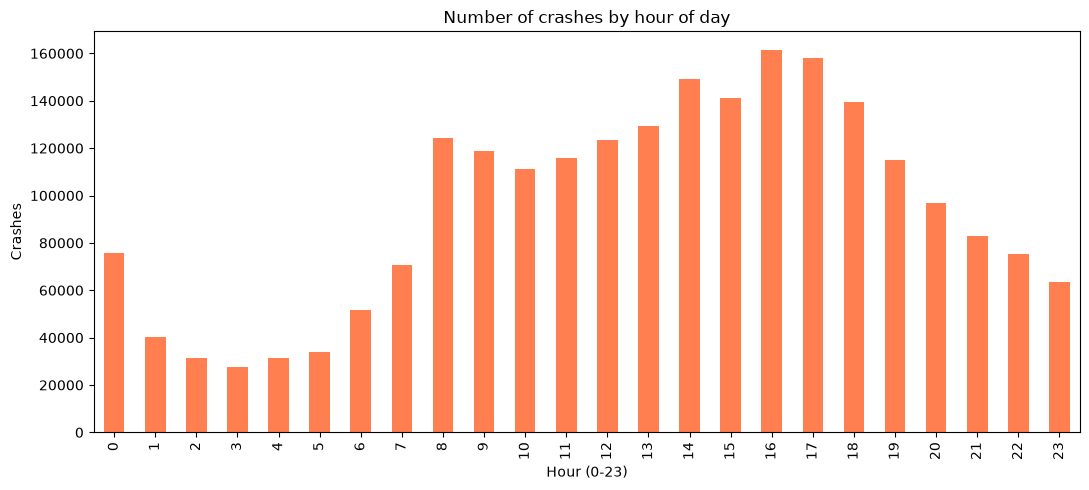

In [6]:
ax = t["crashes"].plot(kind="bar", figsize=(11, 5), color="coral")
ax.set_title("Number of crashes by hour of day")
ax.set_xlabel("Hour (0-23)"); ax.set_ylabel("Crashes")
plt.tight_layout(); plt.show()

## 4. Hypothesis 3 — Most dangerous cross streets

We build an intersection from `on_street_name` + `off_street_name` (in this dataset
`off_street_name` holds the cross street) and rank intersections by total people injured + killed.

In [7]:
d = df.dropna(subset=["on_street_name", "off_street_name"]).copy()
d["intersection"] = d["on_street_name"].str.strip() + " & " + d["off_street_name"].str.strip()
d["casualties"] = (d["number_of_persons_injured"].fillna(0)
                   + d["number_of_persons_killed"].fillna(0))

top = (d.groupby("intersection")["casualties"].sum()
         .sort_values(ascending=False).head(10))
print("Most dangerous intersection:", top.index[0])
top.to_frame("total_casualties")

Most dangerous intersection: ROCKAWAY BOULEVARD & BROOKVILLE BOULEVARD


,total_casualties
intersection,
ROCKAWAY BOULEVARD & BROOKVILLE BOULEVARD,437.0
WEST FORDHAM ROAD & MAJOR DEEGAN EXPRESSWAY,296.0
ATLANTIC AVENUE & LOGAN STREET,224.0
BRUCKNER BOULEVARD & EAST 138 STREET,210.0
164 STREET & GRAND CENTRAL PARKWAY,207.0
ROCKAWAY BOULEVARD & BREWER BOULEVARD,205.0
EAST GUN HILL ROAD & BRONX RIVER PARKWAY,200.0
LINDEN BOULEVARD & PENNSYLVANIA AVENUE,194.0
BRUCKNER BOULEVARD & HUNTS POINT AVENUE,190.0


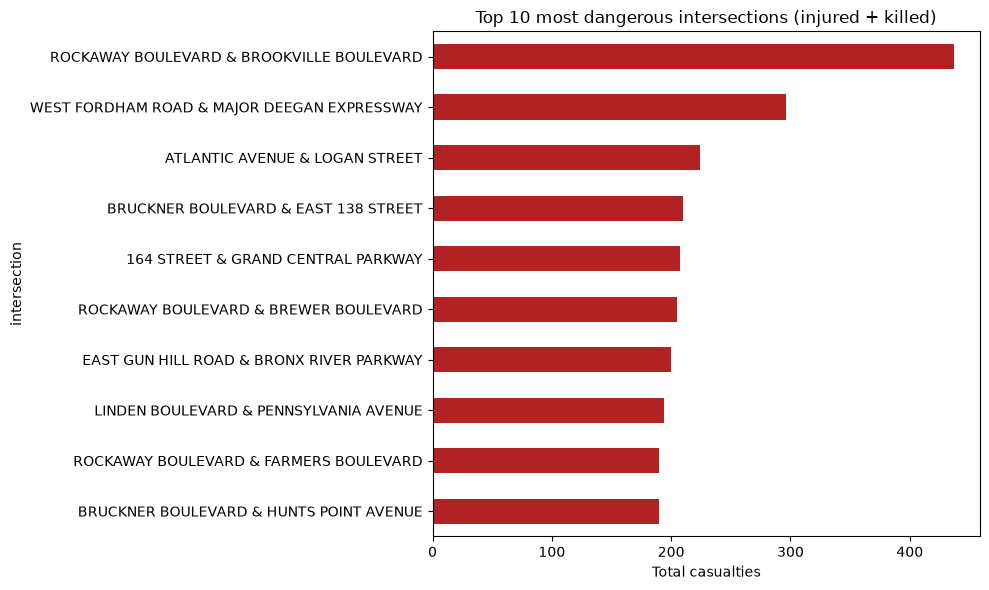

In [8]:
ax = top.sort_values().plot(kind="barh", figsize=(10, 6), color="firebrick")
ax.set_title("Top 10 most dangerous intersections (injured + killed)")
ax.set_xlabel("Total casualties")
plt.tight_layout(); plt.show()

## 5. Hypothesis 4 — Manhattan crashes by time of day

Filter to Manhattan and count crashes per hour to see whether they cluster at a certain time.

In [9]:
man = df[df["borough"] == "Manhattan"].groupby("hour")["collision_id"].count()
print("Manhattan's busiest hour:", man.idxmax(), "with", f"{man.max():,}", "crashes")
man.to_frame("manhattan_crashes")

Manhattan's busiest hour: 16 with 23,648 crashes


,manhattan_crashes
hour,
0,12439
1,7006
2,5265
3,4501
4,4459
5,4265
6,6340
7,8388
8,15763


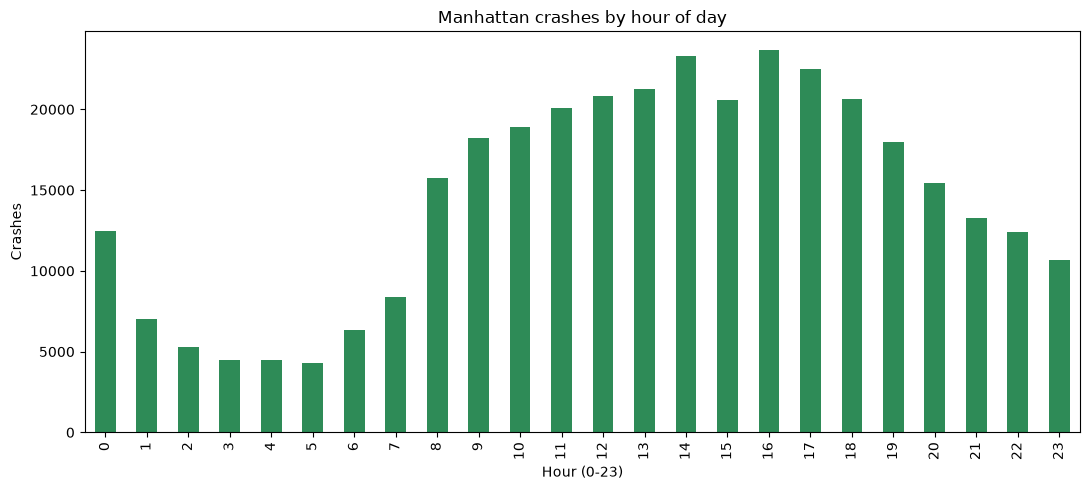

In [10]:
ax = man.plot(kind="bar", figsize=(11, 5), color="seagreen")
ax.set_title("Manhattan crashes by hour of day")
ax.set_xlabel("Hour (0-23)"); ax.set_ylabel("Crashes")
plt.tight_layout(); plt.show()

## Conclusions (read straight off the tables/plots above)

- **H1:** the vehicle type with the lowest average persons killed per crash is the safest.
- **H2:** crashes/injuries peak at the busiest hour shown above (afternoon rush).
- **H3:** the top row of the intersection table is the most dangerous cross street.
- **H4:** Manhattan's tallest bar shows the time of day its crashes concentrate.